In [1]:
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
sn.set(style='whitegrid')

### Step-0: read an image from a bmp file

(np.float64(-0.5), np.float64(319.5), np.float64(213.5), np.float64(-0.5))

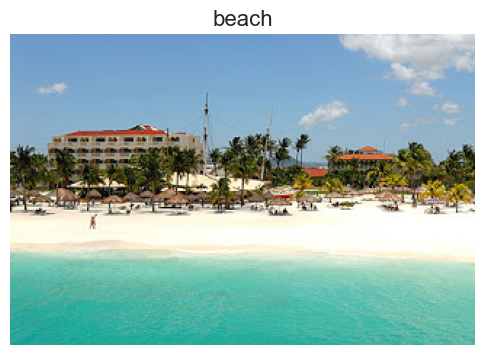

In [2]:
from skimage import io, img_as_float
I = io.imread('beach.bmp')
I = img_as_float(I)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(I)
ax.set_title('beach', fontsize=16)
ax.axis('off')

The image I is a 3D numpy array <br>
I[i,j,k]: i is row index, j is column index, and k is channel (color) index <br>
I[0,0] is the pixel at row-0 and col-0, and it has three values r,g,b

In [3]:
I.shape

(214, 320, 3)

In [4]:
I[0,0]

array([0.43137255, 0.60392157, 0.78823529])

### Step-1: prepare the data matrix X

In [5]:
# I: input image (height x width x 3)
h, w, c = I.shape

# reshape image to (num_pixels, 3)
X = I.reshape(h * w, c)

# convert to float32
X = X.astype(np.float32)


### Step-2: perform k-means on data matrix X


In [6]:
# try different k values
from sklearn.cluster import KMeans
for k in [2, 3, 5, 8, 10]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)          # (H*W,) cluster label for each pixel
    centers = kmeans.cluster_centers_       # (k, 3) RGB centers
    print("k =", k, "| centers shape:", centers.shape, "| labels shape:", labels.shape)

k = 2 | centers shape: (2, 3) | labels shape: (68480,)
k = 3 | centers shape: (3, 3) | labels shape: (68480,)
k = 5 | centers shape: (5, 3) | labels shape: (68480,)
k = 8 | centers shape: (8, 3) | labels shape: (68480,)
k = 10 | centers shape: (10, 3) | labels shape: (68480,)


In [7]:
# centers stores the cluster centers
centers[labels].shape

(68480, 3)

### Step-3: compress the image using the cluster centers

In [8]:
Ic = centers[labels].reshape(h, w, 3)

In [9]:
Ic.shape

(214, 320, 3)

### Step-4: visualize the compressed the image `Ic`

(np.float64(-0.5), np.float64(319.5), np.float64(213.5), np.float64(-0.5))

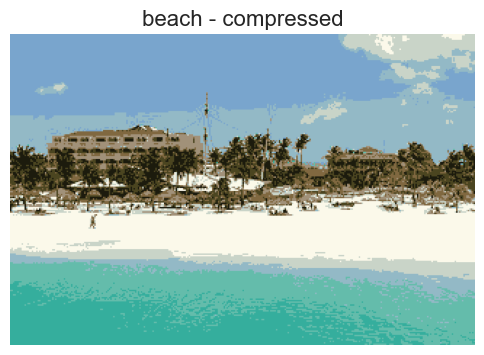

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(Ic)
ax.set_title('beach - compressed', fontsize=16)
ax.axis('off')

### Step-5: save the compressed image to a bmp file

In [11]:
# normalize the pixel values in the range of 0 ~ 255
Is=255*(Ic- Ic.min())/(Ic.max()-Ic.min())
# chagne datay type to unit8
Is=Is.astype('uint8')
io.imsave('beach_compressed_k' + str(k) + '.bmp', Is)